In [1]:
# Load packages
library(dplyr)
library(tidyr)
library(hms)
library(lubridate)
library(ggplot2)
library(purrr)
library(patchwork)
library(tidyverse)
# library(reshape2)
library(stringr)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following object is masked from ‘package:hms’:

    hms


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.1     ✔ stringr 1.5.2
✔ readr   2.1.5     ✔ tibble  3.3.0
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()  masks stats::filter()
✖ lubridate::hms() masks hms::hms()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [5]:
getwd()

[1] "/home/strawperry/Documents/Masters/growth_curves"

In [6]:
pattern <- "^241125_.*h\\.csv$"   # files starting with 181125 and ending in h.csv

In [7]:
# ---- FUNCTION TO PROCESS A SINGLE FILE ----
process_plate_file <- function(file) {
  
  # Extract time in hours from filename (number between _ and h)
  time_hr <- sub(".*_(\\d+)h.*", "\\1", basename(file))
  time_hr <- as.numeric(time_hr)
  
  # Import plate data (skip first row, no header)
  raw <- read.csv(file, header = FALSE, skip = 1, na.strings = c("", "NA"))
  
  # Make first column row names
  rownames(raw) <- raw$V1
  raw <- raw[, -1]
  
  # Rename columns to 1–12
  colnames(raw) <- as.character(1:12)
  
  # Convert rownames into column
  raw2 <- raw %>%
    tibble::rownames_to_column("Row")
  
  # Long format: Row + Col → Well
  long <- raw2 %>%
    pivot_longer(-Row, names_to = "Col", values_to = "Value") %>%
    mutate(Well = paste0(Row, Col)) %>%
    select(Well, Value) %>%
    filter(!is.na(Value) & Value != "<NA>")
  
  # Decimal comma → dot
  long$Value <- as.numeric(gsub(",", ".", long$Value))
  
  # Wide format (one row, wells as columns)
  wide <- long %>%
    pivot_wider(names_from = Well, values_from = Value)
  
  # Add time column at the front
  wide <- wide %>%
    mutate(Time_hr = time_hr, .before = 1)
  
  return(wide)
}

# ---- PROCESS ALL MATCHING FILES ----
file_list <- list.files(pattern = pattern)
file_list

[1] "241125_0h.csv"  "241125_10h.csv" "241125_24h.csv" "241125_30h.csv"
[5] "241125_4h.csv"  "241125_6h.csv"  "241125_8h.csv"

In [9]:
all_data <- file_list %>%
  map_dfr(process_plate_file)
head(all_data)

Time_hr,A1,A2,A3,A4,A5,A6,A7,A8,A9,⋯,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0.062,0.070,0.066,0.066,0.081,0.076,0.065,0.062,0.058,⋯,0.040,0.051,0.050,0.050,0.052,0.052,0.050,0.050,0.054,0.052
10,0.155,0.171,0.169,0.088,0.098,0.093,0.076,0.073,0.062,⋯,0.042,0.048,0.049,0.050,0.051,0.059,0.049,0.050,0.050,0.048
24,0.206,0.206,0.213,0.179,0.178,0.199,0.172,0.166,0.133,⋯,0.043,0.051,0.058,0.050,0.054,0.043,0.049,0.050,0.050,0.048
30,0.211,0.209,0.201,0.176,0.166,0.212,0.164,0.181,0.147,⋯,0.039,0.053,0.051,0.051,0.056,0.056,0.074,0.051,0.051,0.048
4,0.095,0.103,0.102,0.073,0.076,0.076,0.062,0.068,0.056,⋯,0.042,0.050,0.049,0.050,0.051,0.053,0.051,0.051,0.050,0.051
6,0.103,0.111,0.122,0.072,0.088,0.079,0.066,0.067,0.057,⋯,0.042,0.050,0.049,0.050,0.051,0.051,0.051,0.050,0.050,0.051


In [10]:
desired_levels <- c(0, 2, 4, 6, 8, 10, 24, 30) # put the time points measured here 

all_data <- all_data %>%
  mutate(Time_hr = factor(Time_hr, levels = desired_levels))

head(all_data)

Time_hr,A1,A2,A3,A4,A5,A6,A7,A8,A9,⋯,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0.062,0.070,0.066,0.066,0.081,0.076,0.065,0.062,0.058,⋯,0.040,0.051,0.050,0.050,0.052,0.052,0.050,0.050,0.054,0.052
10,0.155,0.171,0.169,0.088,0.098,0.093,0.076,0.073,0.062,⋯,0.042,0.048,0.049,0.050,0.051,0.059,0.049,0.050,0.050,0.048
24,0.206,0.206,0.213,0.179,0.178,0.199,0.172,0.166,0.133,⋯,0.043,0.051,0.058,0.050,0.054,0.043,0.049,0.050,0.050,0.048
30,0.211,0.209,0.201,0.176,0.166,0.212,0.164,0.181,0.147,⋯,0.039,0.053,0.051,0.051,0.056,0.056,0.074,0.051,0.051,0.048
4,0.095,0.103,0.102,0.073,0.076,0.076,0.062,0.068,0.056,⋯,0.042,0.050,0.049,0.050,0.051,0.053,0.051,0.051,0.050,0.051
6,0.103,0.111,0.122,0.072,0.088,0.079,0.066,0.067,0.057,⋯,0.042,0.050,0.049,0.050,0.051,0.051,0.051,0.050,0.050,0.051


In [11]:
od_tp <- all_data

In [12]:
# --- Helper function to reshape and annotate ---
reshape_od <- function(df, medium_label) {
  df %>%
    pivot_longer(-Time_hr, names_to = "Well", values_to = "OD") %>%
    mutate(
      Medium = medium_label,
      Well = str_trim(Well),  # clean any spaces
      Row = str_extract(Well, "^[A-H]"),
      Col = as.numeric(str_extract(Well, "\\d+")),  # correctly capture digits
      Carbon = case_when(
        Col %in% c(1, 2, 3)  ~ "M9_GLU",
        Col %in% c(4, 5, 6) ~ "M9_SIA",
        Col %in% c(7, 8, 9) ~ "M9",
        TRUE ~ NA_character_
      ),
      Strain = case_when(
        Row %in% c("A", "B", "C") ~ "USA300",
        Row %in% c("E", "F", "G") ~ "HC-B1",
        Row %in% "H" ~ "Blank",
        TRUE ~ NA_character_
      ),
      OD = as.numeric(OD)
    )
}

# Apply to both
od_tp_long <- reshape_od(od_tp, "M9")

In [13]:
head(od_tp_long)

Time_hr,Well,OD,Medium,Row,Col,Carbon,Strain
<fct>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
0,A1,0.062,M9,A,1,M9_GLU,USA300
0,A2,0.070,M9,A,2,M9_GLU,USA300
0,A3,0.066,M9,A,3,M9_GLU,USA300
0,A4,0.066,M9,A,4,M9_SIA,USA300
0,A5,0.081,M9,A,5,M9_SIA,USA300
0,A6,0.076,M9,A,6,M9_SIA,USA300


In [14]:
# Remove unwanted wells
od_tp_long2 <- od_tp_long %>%
  filter(
    !Row %in% "D", !Col %in% c(10, 11, 12))
head(od_tp_long2)

Time_hr,Well,OD,Medium,Row,Col,Carbon,Strain
<fct>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
0,A1,0.062,M9,A,1,M9_GLU,USA300
0,A2,0.070,M9,A,2,M9_GLU,USA300
0,A3,0.066,M9,A,3,M9_GLU,USA300
0,A4,0.066,M9,A,4,M9_SIA,USA300
0,A5,0.081,M9,A,5,M9_SIA,USA300
0,A6,0.076,M9,A,6,M9_SIA,USA300


In [15]:
write_tsv(od_tp_long2, "saureus_m9_ox_241125.tsv")

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'


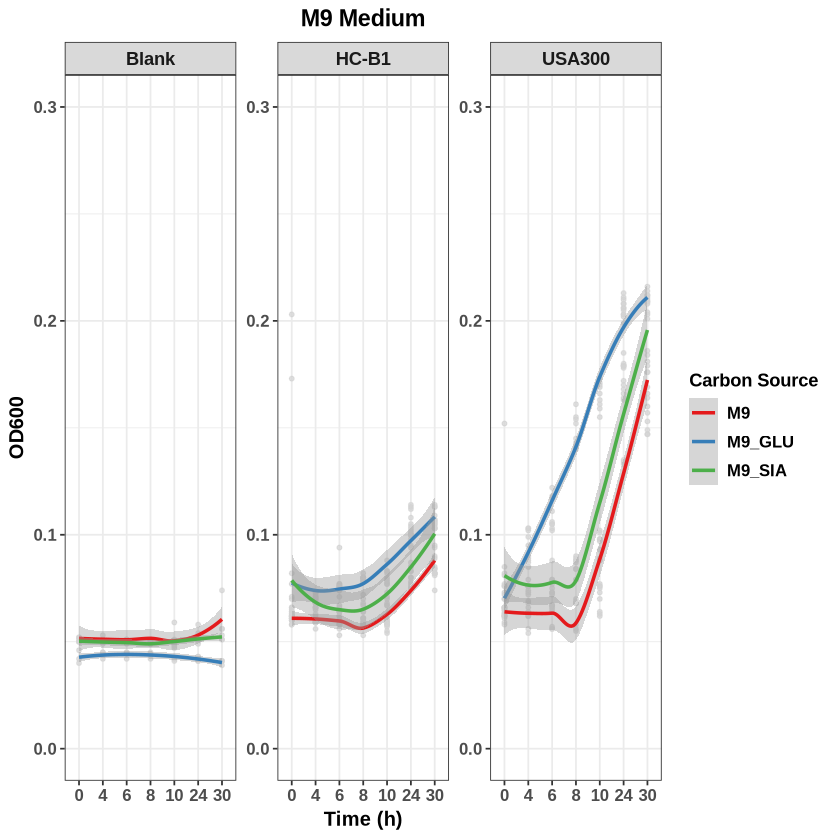

In [16]:
plotA <- ggplot(
  od_tp_long2 %>%
    filter(!is.na(Carbon), Carbon != "Blank"),  # remove blanks and NAs
  aes(x = Time_hr, y = OD)
) +
  # Raw measurements in light gray
  geom_point(aes(group = Well), color = "lightgray", size = 1.0, alpha = 0.7) +
  # Loess trend colored by Carbon
  geom_smooth(aes(color = Carbon, group = Carbon),
              method = "loess", span = 0.8, se = TRUE, size = 1) +
  facet_wrap(~Strain, scales = "free_y") +
  scale_color_brewer(palette = "Set1") +
  labs(
    x = "Time (h)",
    y = "OD600",
    color = "Carbon Source",
    title = "M9 Medium"
  ) +
  scale_y_continuous(limits = c(0, 0.30)) +  # fix y-axis across all facets
  theme_bw() +
  theme(
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(face = "bold", size = 10),
    strip.text = element_text(face = "bold", size = 11),
    legend.title = element_text(face = "bold", size = 11),
    legend.text = element_text(face = "bold", size = 10),
    plot.title = element_text(face = "bold", size = 14, hjust = 0.5)
  )

plotA

In [27]:
od_tp_long2 <- read_tsv("od_tp_long2.tsv")

Rows: 172 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (5): Well, Medium, Row, Carbon, Strain
dbl (3): Time_hr, OD, Col

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


`geom_smooth()` using formula = 'y ~ x'


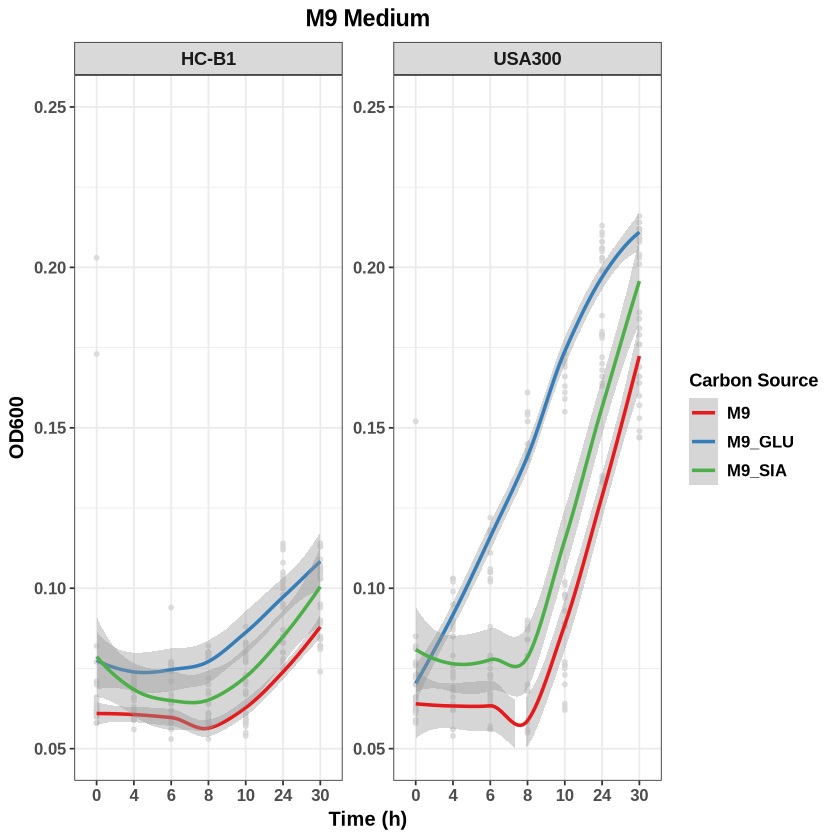

In [26]:
plotA <- ggplot(
  od_tp_long2 %>%
    filter(!is.na(Carbon), Strain != "Blank"),  # remove blanks and NAs
  aes(x = Time_hr, y = OD)
) +
  # Raw measurements in light gray
  geom_point(aes(group = Well), color = "lightgray", size = 1.0, alpha = 0.7) +
  # Loess trend colored by Carbon
  geom_smooth(aes(color = Carbon, group = Carbon),
              method = "loess", span = 0.8, se = TRUE, size = 1) +
  facet_wrap(~Strain, scales = "free_y") +
  scale_color_brewer(palette = "Set1") +
  labs(
    x = "Time (h)",
    y = "OD600",
    color = "Carbon Source",
    title = "M9 Medium"
  ) +
  scale_y_continuous(limits = c(0.05, 0.25)) +  # fix y-axis across all facets
  theme_bw() +
  theme(
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(face = "bold", size = 10),
    strip.text = element_text(face = "bold", size = 11),
    legend.title = element_text(face = "bold", size = 11),
    legend.text = element_text(face = "bold", size = 10),
    plot.title = element_text(face = "bold", size = 14, hjust = 0.5)
  )

plotA